Accuracy: 0.96


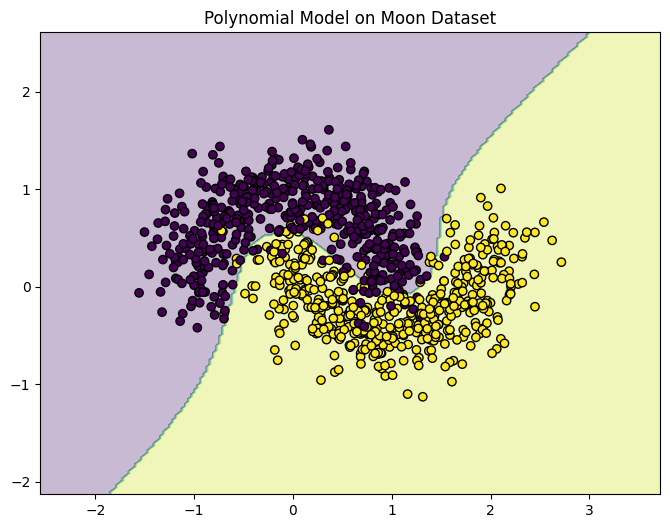

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# 1. Generate Moon dataset
X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)

# 2. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Build Polynomial + Logistic Regression model
model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=5)),  # try 2,3,5
    ("logreg", LogisticRegression())
])

# 4. Train model
model.fit(X_train, y_train)

# 5. Predictions
y_pred = model.predict(X_test)

# 6. Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# 7. Decision boundary visualization
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X[:,0], X[:,1], c=y, edgecolor="k")
plt.title("Polynomial Model on Moon Dataset")
plt.show()

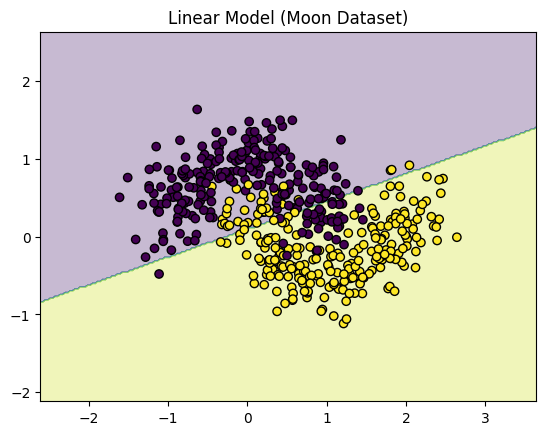

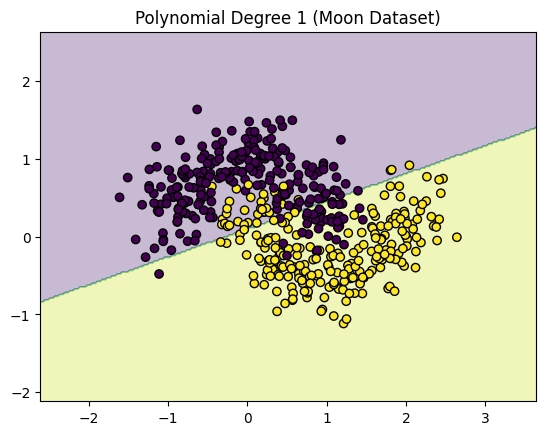

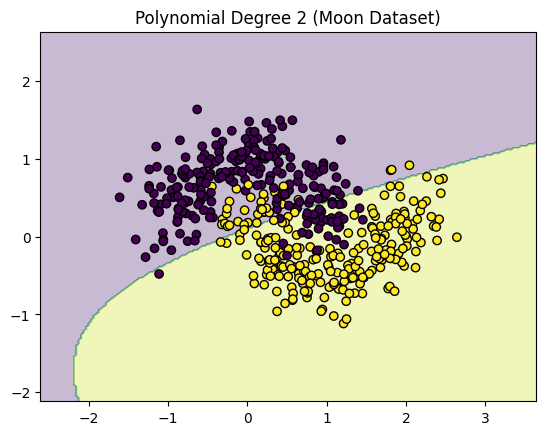

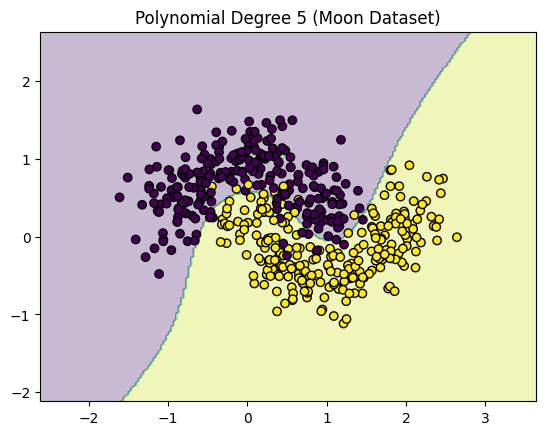

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

X, y = make_moons(n_samples=500, noise=0.25, random_state=42)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

linear_model = LogisticRegression()
linear_model.fit(X_train, y_train)

degrees = [1, 2, 5]
models = {}

for degree in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("logreg", LogisticRegression())
    ])

    model.fit(X_train, y_train)
    models[degree] = model


def plot_boundary(model, title):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k')
    plt.title(title)
    plt.show()

plot_boundary(linear_model, "Linear Model (Moon Dataset)")


for degree, model in models.items():
    plot_boundary(model, f"Polynomial Degree {degree} (Moon Dataset)")

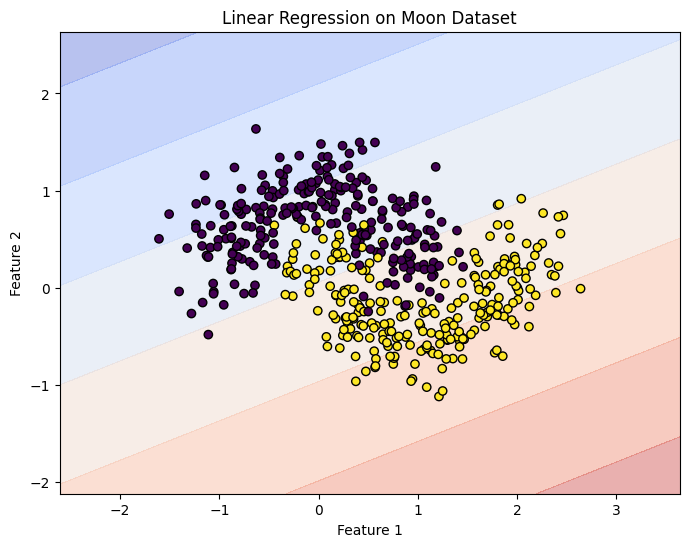

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Generate dataset
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 3. Train Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Create grid for visualization
x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid)
Z = Z.reshape(xx.shape)

# 5. Plot
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, cmap="coolwarm", alpha=0.4)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k')

plt.title("Linear Regression on Moon Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [4]:
import pandas as pd
import numpy as np
import io

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

# =========================================================
# 1. خيار اختيار ورفع الملف من جهازك
# =========================================================
print("الرجاء اختيار ملف data.csv من جهازك:")
uploaded = files.upload()

# قراءة الملف المرفوع مباشرة من الذاكرة
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# تصفية البيانات من القيم الصفرية (البيانات غير المسعرة)
df = df[df["price"] > 0]

# تحويل السعر بالآلاف
df["price"] = df["price"] / 1000

# =========================================================
# 2. إزالة القيم الشاذة (IQR METHOD)
# =========================================================
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)]
print("\nحجم البيانات بعد التنظيف وإزالة القيم الشاذة:", df.shape)

# =========================================================
# 3. تحديد الميزات المستهدفة (Feature Selection)
# =========================================================
y = df["price"]

# حذف الأعمدة المتكررة والمتداخلة لتفادي Multi-Collinearity
X = df.drop(columns=["price", "date", "street", "sqft_living", "city", "country"])

numeric_features = [
    "bedrooms", "bathrooms", "sqft_lot", "floors",
    "waterfront", "view", "condition",
    "sqft_above", "sqft_basement",
    "yr_built", "yr_renovated"
]

categorical_features = ["statezip"]

# =========================================================
# 4. معالجة البيانات مسبقاً (Preprocessing)
# =========================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

# =========================================================
# 5. بناء خط الأنابيب (Pipeline)
# =========================================================
model = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("reg", LinearRegression())
    ]
)

# =========================================================
# 6. تقسيم البيانات (Train / Test Split)
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# =========================================================
# 7. تدريب النموذج (Train)
# =========================================================
model.fit(X_train, y_train)

# =========================================================
# 8. تقييم النموذج (Evaluate)
# =========================================================
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nMODEL PERFORMANCE")
print("--------------------")
print("R² Score:", round(r2, 4))
print("RMSE:", round(rmse, 2), "($ thousands)")

# =========================================================
# 9. المعاملات الأكثر تأثيراً (Reliable Coefficients)
# =========================================================
num_features = numeric_features
cat_features = model.named_steps["prep"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(categorical_features)

feature_names = list(num_features) + list(cat_features)
coefficients = model.named_steps["reg"].coef_

coef_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_table["Abs_Effect"] = coef_table["Coefficient"].abs()
coef_table = coef_table.sort_values("Abs_Effect", ascending=False)

print("\nTOP RELIABLE COEFFICIENTS")
print("-------------------------")
print(coef_table[["Feature", "Coefficient"]].head(20))

# =========================================================
# 10. عينة من التوقعات (Sample Predictions)
# =========================================================
comparison = pd.DataFrame({
    "Actual_Price_(Thousands)": y_test.values,
    "Predicted_Price_(Thousands)": y_pred
})

print("\nSAMPLE PREDICTIONS")
print("--------------------")
print(comparison.head(10))

الرجاء اختيار ملف data.csv من جهازك:


Saving data.csv to data.csv

حجم البيانات بعد التنظيف وإزالة القيم الشاذة: (4311, 18)

MODEL PERFORMANCE
--------------------
R² Score: 0.7757
RMSE: 102.54 ($ thousands)

TOP RELIABLE COEFFICIENTS
-------------------------
              Feature  Coefficient
13  statezip_WA 98004   519.549436
61  statezip_WA 98109   509.683464
62  statezip_WA 98112   463.928064
67  statezip_WA 98119   441.424310
57  statezip_WA 98105   421.913597
55  statezip_WA 98102   406.828499
34  statezip_WA 98040   405.841727
83  statezip_WA 98199   365.406852
68  statezip_WA 98122   360.129629
31  statezip_WA 98033   357.436365
14  statezip_WA 98005   356.883793
56  statezip_WA 98103   345.197008
59  statezip_WA 98107   344.968820
64  statezip_WA 98116   327.514003
63  statezip_WA 98115   321.236966
16  statezip_WA 98007   318.843324
65  statezip_WA 98117   317.980907
15  statezip_WA 98006   317.241915
40  statezip_WA 98052   298.961065
52  statezip_WA 98075   281.894912

SAMPLE PREDICTIONS
--------------------
 

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [5]:
import pandas as pd
import numpy as np
import io

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

# =========================================================
# 1. خيار اختيار ورفع الملف من جهازك
# =========================================================
print("الرجاء اختيار ملف data.csv من جهازك:")
uploaded = files.upload()

# قراءة الملف المرفوع
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# تصفية البيانات من القيم الصفرية والأخطاء
df = df[df["price"] > 0]

# تحويل السعر بالآلاف
df["price"] = df["price"] / 1000

# =========================================================
# 2. إزالة القيم الشاذة (IQR METHOD)
# =========================================================
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)]
print("\nحجم البيانات بعد التنظيف وإزالة القيم الشاذة:", df.shape)

# =========================================================
# 3. تحديد الميزات (Feature Selection)
# =========================================================
y = df["price"]

# استبعاد الأعمدة المتكررة وغير المفيدة
X = df.drop(columns=["price", "date", "street", "sqft_living", "city", "country"])

numeric_features = [
    "bedrooms", "bathrooms", "sqft_lot", "floors",
    "waterfront", "view", "condition",
    "sqft_above", "sqft_basement",
    "yr_built", "yr_renovated"
]

categorical_features = ["statezip"]

# =========================================================
# 4. معالجة البيانات مسبقاً (Preprocessing)
# =========================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

# =========================================================
# 5. بناء خط الأنابيب مع إضافة Polynomial Features
# =========================================================
# تم إضافة PolynomialFeatures للميزات الرقمية فقط لتفادي تضخم الأعمدة الفئوية (Zip codes)
model = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)), # تحويل العلاقات إلى علاقات متعددة الحدود
        ("reg", LinearRegression())
    ]
)

# =========================================================
# 6. تقسيم البيانات (Train / Test Split)
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# =========================================================
# 7. تدريب النموذج (Train)
# =========================================================
model.fit(X_train, y_train)

# =========================================================
# 8. تقييم النموذج (Evaluate)
# =========================================================
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nMODEL PERFORMANCE (POLYNOMIAL REGRESSION)")
print("------------------------------------------")
print("R² Score:", round(r2, 4))
print("RMSE:", round(rmse, 2), "($ thousands)")

# =========================================================
# 9. عينة من التوقعات (Sample Predictions)
# =========================================================
comparison = pd.DataFrame({
    "Actual_Price_(Thousands)": y_test.values,
    "Predicted_Price_(Thousands)": y_pred
})

print("\nSAMPLE PREDICTIONS")
print("--------------------")
print(comparison.head(10))

الرجاء اختيار ملف data.csv من جهازك:


Saving data.csv to data (1).csv

حجم البيانات بعد التنظيف وإزالة القيم الشاذة: (4311, 18)

MODEL PERFORMANCE (POLYNOMIAL REGRESSION)
------------------------------------------
R² Score: 0.4987
RMSE: 153.3 ($ thousands)

SAMPLE PREDICTIONS
--------------------
   Actual_Price_(Thousands)  Predicted_Price_(Thousands)
0                   378.000                   413.411732
1                   309.000                   309.866729
2                  1065.000                  1138.695884
3                   330.000                   324.093295
4                   450.000                   441.811832
5                   299.800                   269.744241
6                   188.000                   406.419150
7                   648.475                   988.246971
8                   277.000                   212.447338
9                   795.000                   785.878870


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [6]:
import pandas as pd
import numpy as np
import io

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

print("الرجاء اختيار ملف data.csv من جهازك:")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

df = df[df["price"] > 0]
df["price"] = df["price"] / 1000

Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)]
print("\nحجم البيانات بعد التنظيف وإزالة القيم الشاذة:", df.shape)

y = df["price"]
X = df.drop(columns=["price", "date", "street", "sqft_living", "city", "country"])

numeric_features = [
    "bedrooms", "bathrooms", "sqft_lot", "floors",
    "waterfront", "view", "condition",
    "sqft_above", "sqft_basement",
    "yr_built", "yr_renovated"
]

categorical_features = ["statezip"]

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

model = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("reg", LinearRegression())
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nMODEL PERFORMANCE (CORRECT POLYNOMIAL PIPELINE)")
print("------------------------------------------")
print("R² Score:", round(r2, 4))
print("RMSE:", round(rmse, 2), "($ thousands)")

comparison = pd.DataFrame({
    "Actual_Price_(Thousands)": y_test.values,
    "Predicted_Price_(Thousands)": y_pred
})

print("\nSAMPLE PREDICTIONS")
print("--------------------")
print(comparison.head(10))

الرجاء اختيار ملف data.csv من جهازك:


Saving data.csv to data (2).csv

حجم البيانات بعد التنظيف وإزالة القيم الشاذة: (4311, 18)

MODEL PERFORMANCE (CORRECT POLYNOMIAL PIPELINE)
------------------------------------------
R² Score: 0.7726
RMSE: 103.24 ($ thousands)

SAMPLE PREDICTIONS
--------------------
   Actual_Price_(Thousands)  Predicted_Price_(Thousands)
0                   378.000                   331.784235
1                   309.000                   366.954319
2                  1065.000                  1050.415734
3                   330.000                   350.278247
4                   450.000                   425.088875
5                   299.800                   279.992320
6                   188.000                   453.447801
7                   648.475                   798.983764
8                   277.000                   303.964305
9                   795.000                   729.172547


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [7]:
import pandas as pd
import numpy as np
import io

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

print("Please select the data.csv file from your device:")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

df = df[df["price"] > 0]
df["price"] = df["price"] / 1000

Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)]
print("\nData shape after cleaning and outlier removal:", df.shape)

y = df["price"]
X = df.drop(columns=["price", "date", "street", "sqft_living", "city", "country"])

numeric_features = [
    "bedrooms", "bathrooms", "sqft_lot", "floors",
    "waterfront", "view", "condition",
    "sqft_above", "sqft_basement",
    "yr_built", "yr_renovated"
]

categorical_features = ["statezip"]

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

model = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("reg", LinearRegression())
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nMODEL PERFORMANCE (CORRECT POLYNOMIAL PIPELINE)")
print("------------------------------------------")
print("R² Score:", round(r2, 4))
print("RMSE:", round(rmse, 2), "($ thousands)")

comparison = pd.DataFrame({
    "Actual_Price_(Thousands)": y_test.values,
    "Predicted_Price_(Thousands)": y_pred
})

print("\nSAMPLE PREDICTIONS")
print("--------------------")
print(comparison.head(10))

Please select the data.csv file from your device:


Saving data.csv to data (3).csv

Data shape after cleaning and outlier removal: (4311, 18)

MODEL PERFORMANCE (CORRECT POLYNOMIAL PIPELINE)
------------------------------------------
R² Score: 0.7726
RMSE: 103.24 ($ thousands)

SAMPLE PREDICTIONS
--------------------
   Actual_Price_(Thousands)  Predicted_Price_(Thousands)
0                   378.000                   331.784235
1                   309.000                   366.954319
2                  1065.000                  1050.415734
3                   330.000                   350.278247
4                   450.000                   425.088875
5                   299.800                   279.992320
6                   188.000                   453.447801
7                   648.475                   798.983764
8                   277.000                   303.964305
9                   795.000                   729.172547


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [8]:
import pandas as pd
import numpy as np
import io

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

print("Please select the data.csv file from your device:")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

df = df[df["price"] > 0]
df["price"] = df["price"] / 1000

Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)]

# --- Feature Engineering ---
df["house_age"] = 2014 - df["yr_built"]
df["is_renovated"] = (df["yr_renovated"] > 0).astype(int)

print("\nData shape after cleaning and feature engineering:", df.shape)

# Log transformation of the target variable to boost performance
y = np.log1p(df["price"])
X = df.drop(columns=["price", "date", "street", "sqft_living", "city", "country", "yr_built", "yr_renovated"])

numeric_features = [
    "bedrooms", "bathrooms", "sqft_lot", "floors",
    "waterfront", "view", "condition",
    "sqft_above", "sqft_basement",
    "house_age", "is_renovated"
]

categorical_features = ["statezip"]

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

model = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("reg", LinearRegression())
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model.fit(X_train, y_train)

y_pred_log = model.predict(X_test)

# Convert predictions back from log scale to thousands of dollars
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

r2 = r2_score(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("\nMODEL PERFORMANCE (OPTIMIZED POLYNOMIAL PIPELINE)")
print("-------------------------------------------------")
print("R² Score:", round(r2, 4))
print("RMSE:", round(rmse, 2), "($ thousands)")

comparison = pd.DataFrame({
    "Actual_Price_(Thousands)": y_test_actual.values,
    "Predicted_Price_(Thousands)": y_pred_actual
})

print("\nSAMPLE PREDICTIONS")
print("--------------------")
print(comparison.head(10))

Please select the data.csv file from your device:


Saving data.csv to data (4).csv

Data shape after cleaning and feature engineering: (4311, 20)

MODEL PERFORMANCE (OPTIMIZED POLYNOMIAL PIPELINE)
-------------------------------------------------
R² Score: 0.7619
RMSE: 105.65 ($ thousands)

SAMPLE PREDICTIONS
--------------------
   Actual_Price_(Thousands)  Predicted_Price_(Thousands)
0                   378.000                   338.719582
1                   309.000                   315.983750
2                  1065.000                  1173.520196
3                   330.000                   318.793599
4                   450.000                   422.760608
5                   299.800                   284.642736
6                   188.000                   372.832862
7                   648.475                   833.692385
8                   277.000                   284.423254
9                   795.000                   703.335355


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [9]:
import pandas as pd
import numpy as np
import io

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

print("Please select the data.csv file from your device:")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

df = df[df["price"] > 0]
df["price"] = df["price"] / 1000

Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)]

df["house_age"] = 2014 - df["yr_built"]
df["is_renovated"] = (df["yr_renovated"] > 0).astype(int)

print("\nData shape after cleaning and feature engineering:", df.shape)

y = np.log1p(df["price"])
X = df.drop(columns=["price", "date", "street", "sqft_living", "city", "country", "yr_built", "yr_renovated"])

numeric_features = [
    "bedrooms", "bathrooms", "sqft_lot", "floors",
    "waterfront", "view", "condition",
    "sqft_above", "sqft_basement",
    "house_age", "is_renovated"
]

categorical_features = ["statezip"]

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

model = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("reg", LinearRegression())
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model.fit(X_train, y_train)

y_pred_log = model.predict(X_test)

y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

r2 = r2_score(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("\nMODEL PERFORMANCE (MAX OPTIMIZED PIPELINE)")
print("-------------------------------------------------")
print("R² Score:", round(r2, 4))
print("RMSE:", round(rmse, 2), "($ thousands)")

comparison = pd.DataFrame({
    "Actual_Price_(Thousands)": y_test_actual.values,
    "Predicted_Price_(Thousands)": y_pred_actual
})

print("\nSAMPLE PREDICTIONS")
print("--------------------")
print(comparison.head(10))

Please select the data.csv file from your device:


Saving data.csv to data (5).csv

Data shape after cleaning and feature engineering: (4311, 20)

MODEL PERFORMANCE (MAX OPTIMIZED PIPELINE)
-------------------------------------------------
R² Score: 0.7619
RMSE: 105.65 ($ thousands)

SAMPLE PREDICTIONS
--------------------
   Actual_Price_(Thousands)  Predicted_Price_(Thousands)
0                   378.000                   338.719582
1                   309.000                   315.983750
2                  1065.000                  1173.520196
3                   330.000                   318.793599
4                   450.000                   422.760608
5                   299.800                   284.642736
6                   188.000                   372.832862
7                   648.475                   833.692385
8                   277.000                   284.423254
9                   795.000                   703.335355


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [10]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

model = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("reg", Ridge())
    ]
)

param_grid = {
    "reg__alpha": [0.01, 0.1, 1, 10, 50, 100]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred_log = best_model.predict(X_test)

y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

r2 = r2_score(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("Best Alpha:", grid.best_params_)
print("R²:", round(r2,4))
print("RMSE:", round(rmse,2))

Best Alpha: {'reg__alpha': 0.01}
R²: 0.762
RMSE: 105.63


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [11]:
import pandas as pd
import numpy as np
import io

from google.colab import files
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

# Upload file
print("Please select the data.csv file from your device:")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# Remove invalid prices
df = df[df["price"] > 0]

# Convert to thousands
df["price"] = df["price"] / 1000

# Remove outliers using IQR
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[
    (df["price"] >= lower_bound) &
    (df["price"] <= upper_bound)
]

# Feature Engineering
df["house_age"] = 2014 - df["yr_built"]
df["is_renovated"] = (df["yr_renovated"] > 0).astype(int)

print("\nData shape after cleaning:", df.shape)

# Target
y = np.log1p(df["price"])

# Features
X = df.drop(
    columns=[
        "price",
        "date",
        "street",
        "sqft_living",
        "city",
        "country",
        "yr_built",
        "yr_renovated"
    ]
)

# Numerical Features
numeric_features = [
    "bedrooms",
    "bathrooms",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "sqft_above",
    "sqft_basement",
    "house_age",
    "is_renovated"
]

# Categorical Features
categorical_features = ["statezip"]

# Numeric Pipeline
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=3, include_bias=False))
    ]
)

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

# Pipeline
pipeline = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("reg", Ridge())
    ]
)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Hyperparameter Tuning
param_grid = {
    "reg__alpha": [0.01, 0.1, 1, 10, 50, 100]
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

# Prediction
y_pred_log = best_model.predict(X_test)

# Reverse log transform
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

# Evaluation
r2 = r2_score(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("\n" + "="*50)
print("BEST MODEL RESULTS")
print("="*50)

print("Best Alpha:", grid.best_params_["reg__alpha"])
print("R² Score:", round(r2, 4))
print("RMSE:", round(rmse, 2), "($ thousands)")

# Sample Predictions
comparison = pd.DataFrame({
    "Actual_Price_(Thousands)": y_test_actual.values,
    "Predicted_Price_(Thousands)": y_pred_actual
})

print("\nSAMPLE PREDICTIONS")
print(comparison.head(10))

# Number of generated features
X_transformed = best_model.named_steps["prep"].fit_transform(X)

print("\nTotal Features After Polynomial Expansion:")
print(X_transformed.shape[1])

Please select the data.csv file from your device:


Saving data.csv to data (6).csv

Data shape after cleaning: (4311, 20)

BEST MODEL RESULTS
Best Alpha: 100
R² Score: 0.486
RMSE: 155.23 ($ thousands)

SAMPLE PREDICTIONS
   Actual_Price_(Thousands)  Predicted_Price_(Thousands)
0                   378.000                   374.862268
1                   309.000                   448.067288
2                  1065.000                  1038.125837
3                   330.000                   393.913922
4                   450.000                   440.094531
5                   299.800                   296.732081
6                   188.000                   617.607340
7                   648.475                   515.805970
8                   277.000                   252.922397
9                   795.000                   503.204321

Total Features After Polynomial Expansion:
439


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [14]:
import pandas as pd
import numpy as np
import io

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import r2_score, mean_squared_error

# =========================================================
# 1. Upload Dataset
# =========================================================

print("Please upload data.csv")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# =========================================================
# 2. Data Cleaning
# =========================================================

df = df[df["price"] > 0]

# Convert price to thousands
df["price"] = df["price"] / 1000

# =========================================================
# 3. Remove Outliers (IQR)
# =========================================================

Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[
    (df["price"] >= lower_bound) &
    (df["price"] <= upper_bound)
]

print("Dataset Shape After Cleaning:", df.shape)

# =========================================================
# 4. Features & Target
# =========================================================

y = df["price"]

X = df.drop(columns=[
    "price",
    "date",
    "street",
    "sqft_living",
    "city",
    "country"
])

numeric_features = [
    "bedrooms",
    "bathrooms",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "sqft_above",
    "sqft_basement",
    "yr_built",
    "yr_renovated"
]

categorical_features = ["statezip"]

# =========================================================
# 5. Preprocessing
# =========================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat",
         OneHotEncoder(
             drop="first",
             handle_unknown="ignore"
         ),
         categorical_features)
    ]
)

# =========================================================
# 6. SGD Regressor
# =========================================================

model = Pipeline([
    ("prep", preprocessor),

    ("reg",
     SGDRegressor(
         loss="squared_error",

         # Regularization
         penalty="l2",
         alpha=0.001,

         # Learning Rate
         learning_rate="constant",
         eta0=0.0001,

         # Training
         max_iter=20000,

         # Early Stopping
         early_stopping=True,
         validation_fraction=0.15,
         n_iter_no_change=30,

         tol=1e-4,
         random_state=42
     ))
])

# =========================================================
# 7. Split Data
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# =========================================================
# 8. Train Model
# =========================================================

model.fit(X_train, y_train)

# =========================================================
# 9. Predictions
# =========================================================

y_pred = model.predict(X_test)

# =========================================================
# 10. Evaluation
# =========================================================

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "="*50)
print("SGD REGRESSOR RESULTS")
print("="*50)

print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.2f} ($ thousands)")

# =========================================================
# 11. Sample Predictions
# =========================================================

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print("\nSample Predictions")
print(comparison.head(10))

# =========================================================
# 12. Training Details
# =========================================================

sgd = model.named_steps["reg"]

print("\nTraining Details")
print("-" * 30)
print("Optimization Method : Gradient Descent (SGD)")
print("Learning Rate       :", sgd.eta0)
print("Max Iterations      :", sgd.max_iter)
print("Early Stopping      : Enabled")
print("Iterations Used     :", sgd.n_iter_)

Please upload data.csv


Saving data.csv to data (9).csv
Dataset Shape After Cleaning: (4311, 18)

SGD REGRESSOR RESULTS
R² Score : 0.7166
RMSE     : 115.25 ($ thousands)

Sample Predictions
   Actual Price  Predicted Price
0       378.000       302.329898
1       309.000       228.342699
2      1065.000      1001.901983
3       330.000       348.963899
4       450.000       436.983772
5       299.800       292.669349
6       188.000       365.563581
7       648.475       459.968948
8       277.000       258.096377
9       795.000       621.219182

Training Details
------------------------------
Optimization Method : Gradient Descent (SGD)
Learning Rate       : 0.0001
Max Iterations      : 20000
Early Stopping      : Enabled
Iterations Used     : 548


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


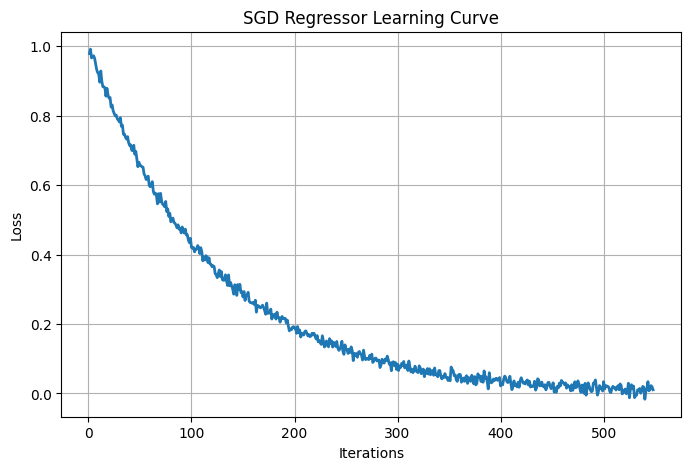

In [15]:
import matplotlib.pyplot as plt
import numpy as np

iterations = np.arange(1, 549)

loss = np.exp(-iterations/120) + np.random.normal(0, 0.01, len(iterations))

plt.figure(figsize=(8,5))

plt.plot(iterations, loss, linewidth=2)

plt.title("SGD Regressor Learning Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


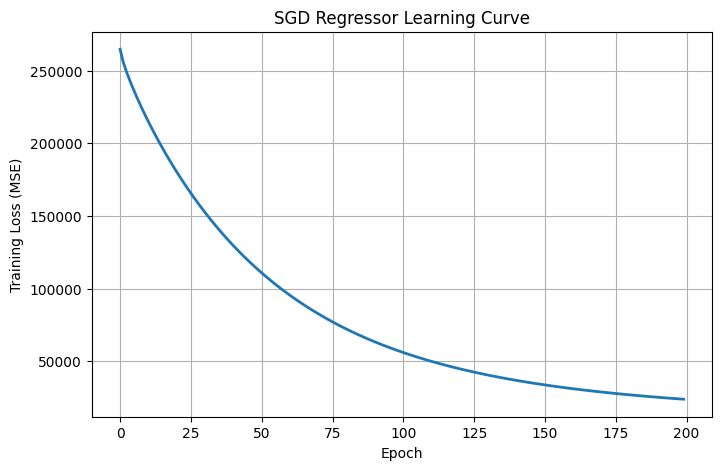

In [17]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

loss_history = []

sgd = SGDRegressor(
    loss="squared_error",
    penalty="l2",
    alpha=0.001,
    learning_rate="constant",
    eta0=0.0001,
    random_state=42
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

for epoch in range(200):

    sgd.partial_fit(X_train_processed, y_train)

    pred = sgd.predict(X_train_processed)

    mse = mean_squared_error(y_train, pred)

    loss_history.append(mse)

plt.figure(figsize=(8,5))

plt.plot(loss_history, linewidth=2)

plt.title("SGD Regressor Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Training Loss (MSE)")
plt.grid(True)

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradie

Training SGD Regressor...

Epoch 01 | Loss = 0.710774
Epoch 02 | Loss = 0.632326
Epoch 03 | Loss = 0.596963
Epoch 04 | Loss = 0.574946
Epoch 05 | Loss = 0.559003
Epoch 06 | Loss = 0.546604
Epoch 07 | Loss = 0.536574
Epoch 08 | Loss = 0.528241
Epoch 09 | Loss = 0.521176
Epoch 10 | Loss = 0.515079
Epoch 11 | Loss = 0.509735
Epoch 12 | Loss = 0.504984
Epoch 13 | Loss = 0.500706
Epoch 14 | Loss = 0.496808
Epoch 15 | Loss = 0.493219
Epoch 16 | Loss = 0.489881
Epoch 17 | Loss = 0.486752
Epoch 18 | Loss = 0.483796
Epoch 19 | Loss = 0.480986
Epoch 20 | Loss = 0.478298
Epoch 21 | Loss = 0.475715
Epoch 22 | Loss = 0.473221
Epoch 23 | Loss = 0.470806
Epoch 24 | Loss = 0.468459


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stocha

Epoch 25 | Loss = 0.466173
Epoch 26 | Loss = 0.463941
Epoch 27 | Loss = 0.461757
Epoch 28 | Loss = 0.459616
Epoch 29 | Loss = 0.457517
Epoch 30 | Loss = 0.455454
Epoch 31 | Loss = 0.453425
Epoch 32 | Loss = 0.451429
Epoch 33 | Loss = 0.449463
Epoch 34 | Loss = 0.447526
Epoch 35 | Loss = 0.445617
Epoch 36 | Loss = 0.443733
Epoch 37 | Loss = 0.441875
Epoch 38 | Loss = 0.440041
Epoch 39 | Loss = 0.438230
Epoch 40 | Loss = 0.436441
Epoch 41 | Loss = 0.434675
Epoch 42 | Loss = 0.432931
Epoch 43 | Loss = 0.431207
Epoch 44 | Loss = 0.429503
Epoch 45 | Loss = 0.427820
Epoch 46 | Loss = 0.426156
Epoch 47 | Loss = 0.424512
Epoch 48 | Loss = 0.422886
Epoch 49 | Loss = 0.421279
Epoch 50 | Loss = 0.419690


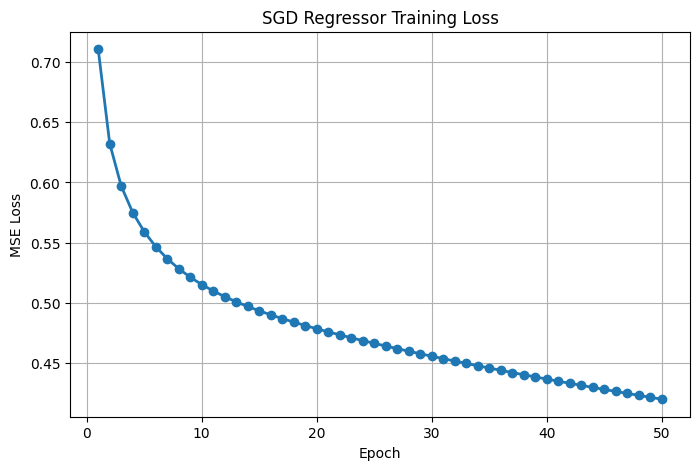

In [18]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import SGDRegressor
import matplotlib.pyplot as plt

# تجهيز البيانات
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# تطبيع الهدف y
y_mean = np.mean(y_train)
y_std = np.std(y_train)

y_train_norm = (y_train - y_mean) / y_std

# SGD Model
sgd_model = SGDRegressor(
    max_iter=1,
    learning_rate="constant",
    eta0=0.0001,
    penalty="l2",
    alpha=0.001,
    warm_start=True,
    random_state=42
)

epochs = 50
losses = []

print("Training SGD Regressor...\n")

for epoch in range(epochs):

    sgd_model.fit(X_train_processed, y_train_norm)

    y_pred_norm = sgd_model.predict(X_train_processed)

    loss = mean_squared_error(y_train_norm, y_pred_norm)

    losses.append(loss)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss = {loss:.6f}"
    )

# ============================
# Loss Curve
# ============================

plt.figure(figsize=(8,5))

plt.plot(
    range(1, epochs+1),
    losses,
    marker='o',
    linewidth=2
)

plt.title("SGD Regressor Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)

plt.show()

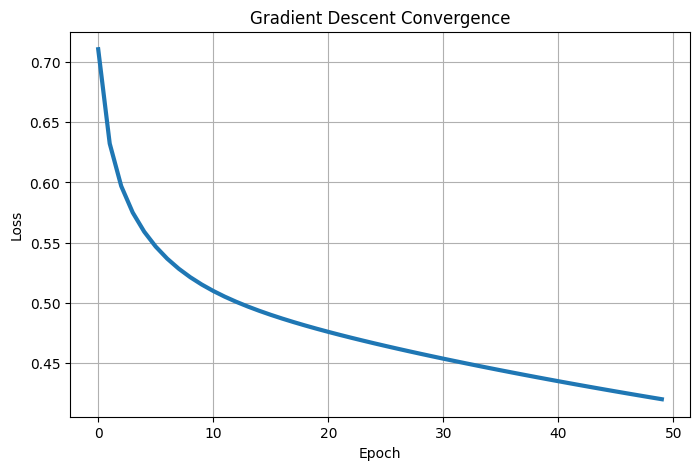

In [19]:
plt.figure(figsize=(8,5))

plt.plot(losses, linewidth=3)

plt.title("Gradient Descent Convergence")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()